## Jay Sanjaykumar Beladiya
### Group 3 DATA 6550
#### Group Project 4


In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind, chi2_contingency
import statsmodels.api as sm
import statsmodels.formula.api as smf

### Section 1: Data Exploration

In [3]:
FILE_PATH = "data/mortgage_covenant_data.csv"   # change path if needed

df = pd.read_csv(FILE_PATH)

In [4]:
print("Shape:", df.shape)

Shape: (100931, 14)


In [5]:
print(df.columns.tolist())

['activity_year', 'census_tract', 'derived_race', 'action_taken', 'loan_amount', 'property_value', 'income', 'interest_rate', 'tract_minority_population_percent', 'tract_to_msa_income_percentage', 'denial_reason-1', 'covenant_count', 'was_approved', 'covenant_density']


In [6]:
print(df.head())

   activity_year  census_tract        derived_race  action_taken  loan_amount  \
0           2023  2.703706e+10  Race Not Available             6     185000.0   
1           2023  2.714103e+10  Race Not Available             6     375000.0   
2           2023  2.702395e+10  Race Not Available             6     105000.0   
3           2023  2.717110e+10  Race Not Available             6     285000.0   
4           2023  2.715948e+10  Race Not Available             6     175000.0   

   property_value  income  interest_rate  tract_minority_population_percent  \
0        195000.0     NaN          6.125                              40.37   
1        385000.0     NaN          6.625                              10.64   
2        105000.0     NaN          6.125                               8.92   
3        285000.0     NaN          6.750                              13.27   
4        175000.0     NaN          6.875                               5.87   

   tract_to_msa_income_percentage  den

In [7]:
# Standardize column names
df.columns = [c.strip().replace(" ", "_").replace("-", "_") for c in df.columns]

# Convert was_approved to integer
if df["was_approved"].dtype != "int64" and df["was_approved"].dtype != "float64":
    df["was_approved"] = df["was_approved"].astype(str).str.lower().map({
        "true": 1, "false": 0
    })


In [8]:
# Numeric conversions
numeric_cols = [
    "loan_amount",
    "property_value",
    "income",
    "interest_rate",
    "tract_minority_population_percent",
    "tract_to_msa_income_percentage",
    "covenant_count"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [9]:
# Clean categorical columns
df["derived_race"] = df["derived_race"].fillna("Unknown").astype(str).str.strip()
df["covenant_density"] = df["covenant_density"].fillna("No Recorded Covenant").astype(str).str.strip()

In [10]:
# Keep only positive numeric values where applicable
for col in ["loan_amount", "property_value", "income", "interest_rate"]:
    df.loc[df[col] <= 0, col] = np.nan

In [11]:
# Check for missing values
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct)


interest_rate                        24.113503
property_value                       17.279131
income                               12.866216
census_tract                          1.006628
activity_year                         0.000000
derived_race                          0.000000
action_taken                          0.000000
loan_amount                           0.000000
tract_minority_population_percent     0.000000
tract_to_msa_income_percentage        0.000000
denial_reason_1                       0.000000
covenant_count                        0.000000
was_approved                          0.000000
covenant_density                      0.000000
dtype: float64


In [12]:
df["historically_covenanted"] = np.where(df["covenant_count"] > 0, 1, 0)

# Create grouped covenant count bands
def covenant_band(x):
    if pd.isna(x):
        return "Unknown"
    elif x == 0:
        return "None"
    elif x <= 10:
        return "1-10"
    elif x <= 50:
        return "11-50"
    elif x <= 100:
        return "51-100"
    else:
        return "100+"

df["covenant_count_band"] = df["covenant_count"].apply(covenant_band)


In [13]:
# Minority population groups
df["minority_pct_band"] = pd.cut(
    df["tract_minority_population_percent"],
    bins=[0, 25, 50, 75, 100],
    labels=["0-25%", "25-50%", "50-75%", "75-100%"],
    include_lowest=True
)

In [14]:
# Income relative to metro groups
df["tract_income_band"] = pd.cut(
    df["tract_to_msa_income_percentage"],
    bins=[0, 80, 120, np.inf],
    labels=["Below MSA (<80)", "Middle MSA (80-120)", "Above MSA (>120)"],
    include_lowest=True
)

In [15]:
print("DESCRIPTIVE STATISTICS")
print(df[numeric_cols + ["was_approved"]].describe())

print("\nApproval Rate Overall:")
print(df["was_approved"].mean())

print("\nCovenant Density Distribution:")
print(df["covenant_density"].value_counts(dropna=False))

DESCRIPTIVE STATISTICS
        loan_amount  property_value        income  interest_rate  \
count  1.009310e+05    8.349100e+04  8.794500e+04   76593.000000   
mean   3.110060e+05    3.987726e+05  1.498266e+02       6.706598   
std    7.617088e+05    1.197102e+06  5.575683e+03       0.878101   
min    5.000000e+03    5.000000e+03  1.000000e+00       0.045900   
25%    1.750000e+05    2.350000e+05  6.700000e+01       6.250000   
50%    2.650000e+05    3.250000e+05  9.600000e+01       6.750000   
75%    3.650000e+05    4.350000e+05  1.460000e+02       7.125000   
max    5.700500e+07    1.113250e+08  1.651000e+06      15.500000   

       tract_minority_population_percent  tract_to_msa_income_percentage  \
count                      100931.000000                   100931.000000   
mean                           22.874029                      101.813583   
std                            17.292952                       32.381060   
min                             0.000000                    

### Section 2: Data Bias Analysis 

In [16]:
# Property values by historical covenant status
property_by_covenant = (
    df.groupby("historically_covenanted")["property_value"]
    .agg(["count", "mean", "median", "std"])
)
print("\nProperty Value by Historical Covenant Status:")
print(property_by_covenant)


Property Value by Historical Covenant Status:
                         count           mean    median           std
historically_covenanted                                              
0                        74110  387560.383214  315000.0  1.217206e+06
1                         9381  487349.429698  355000.0  1.020242e+06


In [17]:
# Property values by covenant_count_band
property_by_band = (
    df.groupby("covenant_count_band")["property_value"]
    .agg(["count", "mean", "median", "std"])
    .sort_index()
)
print("\nProperty Value by Covenant Count Band:")
print(property_by_band)


Property Value by Covenant Count Band:
                     count           mean    median           std
covenant_count_band                                              
1-10                  2354  411588.785047  325000.0  3.188867e+05
100+                  4098  521232.308443  385000.0  1.108950e+06
11-50                 1425  430796.491228  335000.0  3.732720e+05
51-100                1504  567187.500000  365000.0  1.682592e+06
None                 74110  387560.383214  315000.0  1.217206e+06


In [18]:
# Neighborhood characteristics by covenant status
neighborhood_by_covenant = (
    df.groupby("historically_covenanted")[[
        "tract_minority_population_percent",
        "tract_to_msa_income_percentage",
        "income"
    ]]
    .mean()
)
print("\nNeighborhood Characteristics by Historical Covenant Status:")
print(neighborhood_by_covenant)


Neighborhood Characteristics by Historical Covenant Status:
                         tract_minority_population_percent  \
historically_covenanted                                      
0                                                21.940751   
1                                                30.374508   

                         tract_to_msa_income_percentage      income  
historically_covenanted                                              
0                                            100.679432  147.689739  
1                                            110.928425  167.243159  


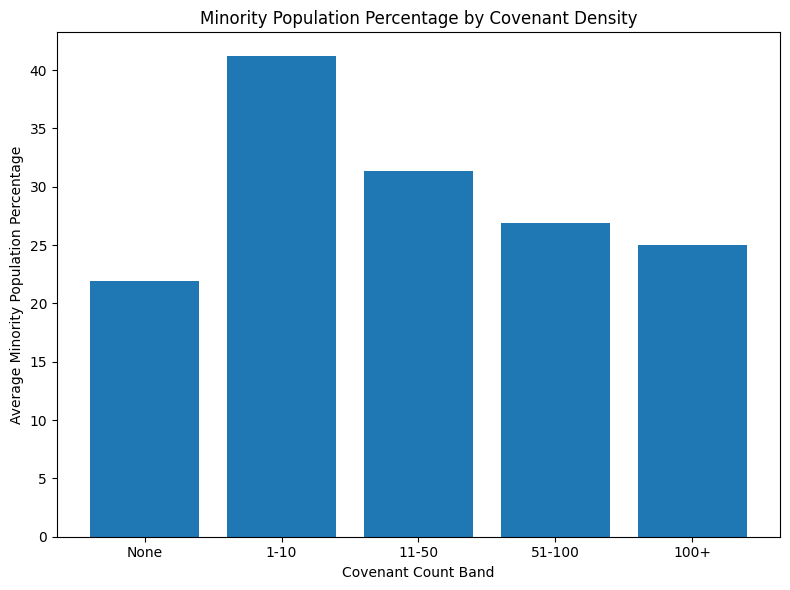

In [19]:
import matplotlib.pyplot as plt

band_order = ["None", "1-10", "11-50", "51-100", "100+"]
minority_density = df.groupby("covenant_count_band")["tract_minority_population_percent"].mean()
minority_density = minority_density.reindex(band_order)

plt.figure(figsize=(8, 6))
plt.bar(minority_density.index, minority_density.values)

plt.title("Minority Population Percentage by Covenant Density")
plt.xlabel("Covenant Count Band")
plt.ylabel("Average Minority Population Percentage")

plt.tight_layout()
plt.show()

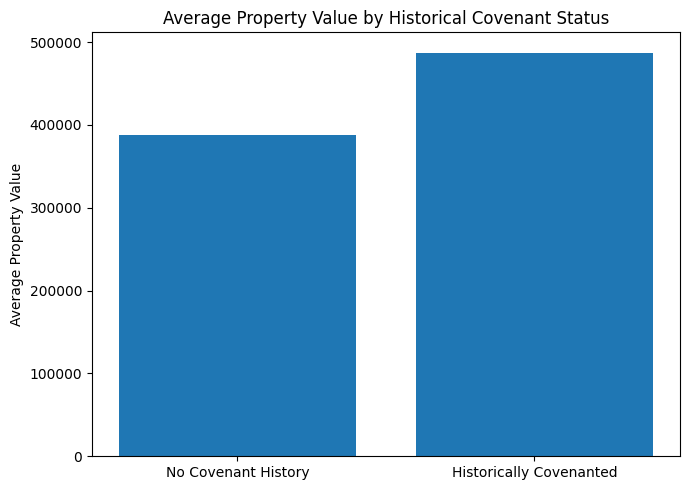

In [20]:
import matplotlib.pyplot as plt

avg_prop = df.groupby("historically_covenanted")["property_value"].mean()

plt.figure(figsize=(7, 5))
plt.bar(["No Covenant History", "Historically Covenanted"], avg_prop.values)

plt.title("Average Property Value by Historical Covenant Status")
plt.ylabel("Average Property Value")

plt.tight_layout()
plt.show()

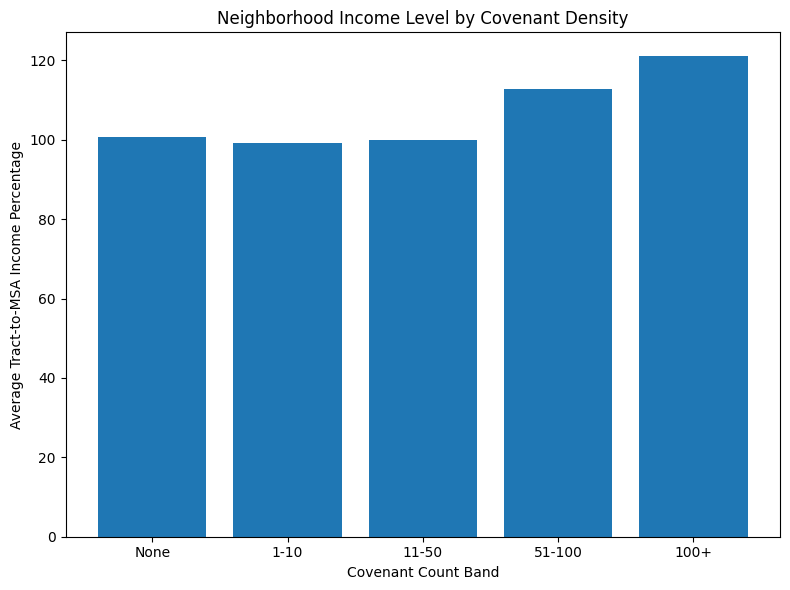

In [21]:
import matplotlib.pyplot as plt

band_order = ["None", "1-10", "11-50", "51-100", "100+"]
income_density = df.groupby("covenant_count_band")["tract_to_msa_income_percentage"].mean()
income_density = income_density.reindex(band_order)

plt.figure(figsize=(8, 6))
plt.bar(income_density.index, income_density.values)

plt.title("Neighborhood Income Level by Covenant Density")
plt.xlabel("Covenant Count Band")
plt.ylabel("Average Tract-to-MSA Income Percentage")

plt.tight_layout()
plt.show()

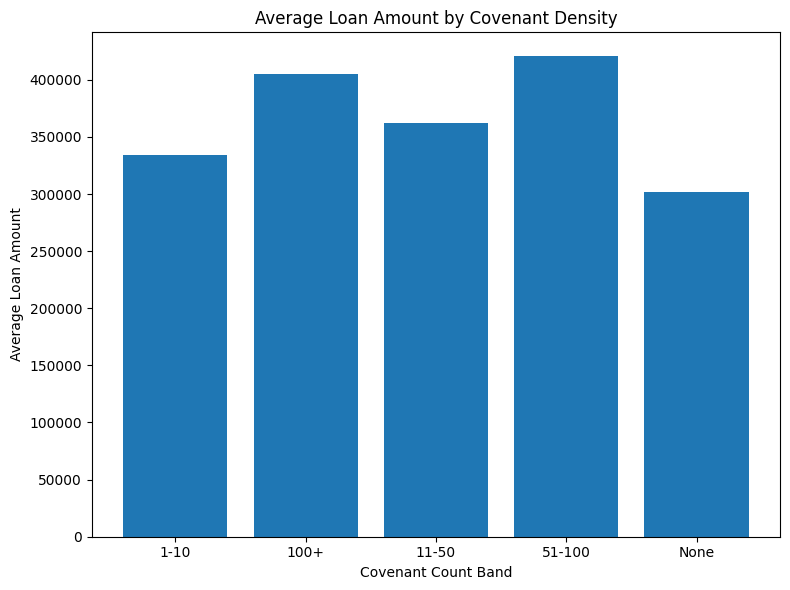

In [22]:
loan_by_covenant = df.groupby("covenant_count_band")["loan_amount"].mean()

plt.figure(figsize=(8,6))
plt.bar(loan_by_covenant.index, loan_by_covenant.values)

plt.title("Average Loan Amount by Covenant Density")
plt.xlabel("Covenant Count Band")
plt.ylabel("Average Loan Amount")

plt.tight_layout()
plt.show()

### Data Bias Analysis

The analysis indicates that historical covenant activity is related to differences in neighborhood economic conditions, where neighborhoods with more historical covenants have higher average property values and different demographic characteristics than neighborhoods without historical covenants. These findings indicate that neighborhoods that had restricted property rights in the past may have had greater long-run investment and property value appreciation.

The neighborhood demographic indicators also vary across the covenant density categories. The census tracts that had historical covenants have differences in minority percentage and income levels in comparison to the metropolitan area. These differences in income and minority levels are long-run residential patterns that emerged during the period in which racially restrictive housing practices were prevalent.

These findings illustrate that current-day housing data may already reflect structural inequalities that arose due to historical policies. If current financial systems utilize current-day data, then the inequalities that are embedded in the data are an example of data bias, where historical inequalities are influencing current-day decision-making.

### Section 3: Algorithmic Bias Analysis

In [23]:
def simplify_race(x):
    x = str(x).strip()
    if x in ["White", "Black or African American", "Asian",
             "American Indian or Alaska Native",
             "Native Hawaiian or Other Pacific Islander",
             "Joint"]:
        return x
    elif "Not Available" in x or "Free Form" in x or x == "Unknown":
        return "Unknown/Not Available"
    else:
        return "Other"

df["race_group"] = df["derived_race"].apply(simplify_race)

In [24]:
# Approval by race
approval_by_race = (
    df.groupby("race_group")["was_approved"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)
print("\nApproval Rate by Race:")
print(approval_by_race)


Approval Rate by Race:
                                           count      mean
race_group                                                
White                                      63627  0.756063
Joint                                       2427  0.744129
Asian                                       5905  0.707705
Other                                        135  0.659259
American Indian or Alaska Native             709  0.622003
Black or African American                   5199  0.604155
Native Hawaiian or Other Pacific Islander    113  0.566372
Unknown/Not Available                      22816  0.405812


In [25]:
# Approval by covenant density
approval_by_density = (
    df.groupby("covenant_density")["was_approved"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)
print("\nApproval Rate by Covenant Density:")
print(approval_by_density)


Approval Rate by Covenant Density:
                      count      mean
covenant_density                     
High (101-200)         1720  0.692442
Very High (>200)       3140  0.673885
Medium (51-100)        1772  0.670429
No Recorded Covenant  89762  0.663867
Low (1-50)             4537  0.661230


In [26]:
# Approval by covenant count band
approval_by_band = (
    df.groupby("covenant_count_band")["was_approved"]
    .agg(["count", "mean"])
    .sort_index()
)
print("\nApproval Rate by Covenant Count Band:")
print(approval_by_band)


Approval Rate by Covenant Count Band:
                     count      mean
covenant_count_band                 
1-10                  2840  0.655282
100+                  4860  0.680453
11-50                 1697  0.671184
51-100                1772  0.670429
None                 89762  0.663867


In [27]:
# Approval by minority band
approval_by_minority = (
    df.groupby("minority_pct_band")["was_approved"]
    .agg(["count", "mean"])
)
print("\nApproval Rate by Minority Population Band:")
print(approval_by_minority)


Approval Rate by Minority Population Band:
                   count      mean
minority_pct_band                 
0-25%              66975  0.675147
25-50%             26235  0.652868
50-75%              5244  0.626621
75-100%             2477  0.586597


In [28]:
# Approval by tract income band
approval_by_tract_income = (
    df.groupby("tract_income_band")["was_approved"]
    .agg(["count", "mean"])
)
print("\nApproval Rate by Tract Income Band:")
print(approval_by_tract_income)


Approval Rate by Tract Income Band:
                     count      mean
tract_income_band                   
Below MSA (<80)      22673  0.617651
Middle MSA (80-120)  53074  0.674643
Above MSA (>120)     25184  0.685951


In [29]:
# Interest rate by approval
interest_by_approval = (
    df.groupby("was_approved")["interest_rate"]
    .agg(["count", "mean", "median", "std"])
)
print("\nInterest Rate by Approval:")
print(interest_by_approval)


Interest Rate by Approval:
              count      mean  median       std
was_approved                                   
0             15910  6.618101   6.725  0.827098
1             60683  6.729800   6.750  0.889542


In [30]:
# Loan amount by approval
loan_by_approval = (
    df.groupby("was_approved")["loan_amount"]
    .agg(["count", "mean", "median", "std"])
)
print("\nLoan Amount by Approval:")
print(loan_by_approval)


Loan Amount by Approval:
              count           mean    median            std
was_approved                                               
0             33846  296500.620457  265000.0  535029.091663
1             67085  318324.290080  275000.0  853433.674215


In [31]:
corr_cols = [
    "was_approved",
    "loan_amount",
    "property_value",
    "income",
    "interest_rate",
    "tract_minority_population_percent",
    "tract_to_msa_income_percentage",
    "covenant_count",
    "historically_covenanted"
]
corr_matrix = df[corr_cols].corr(numeric_only=True)

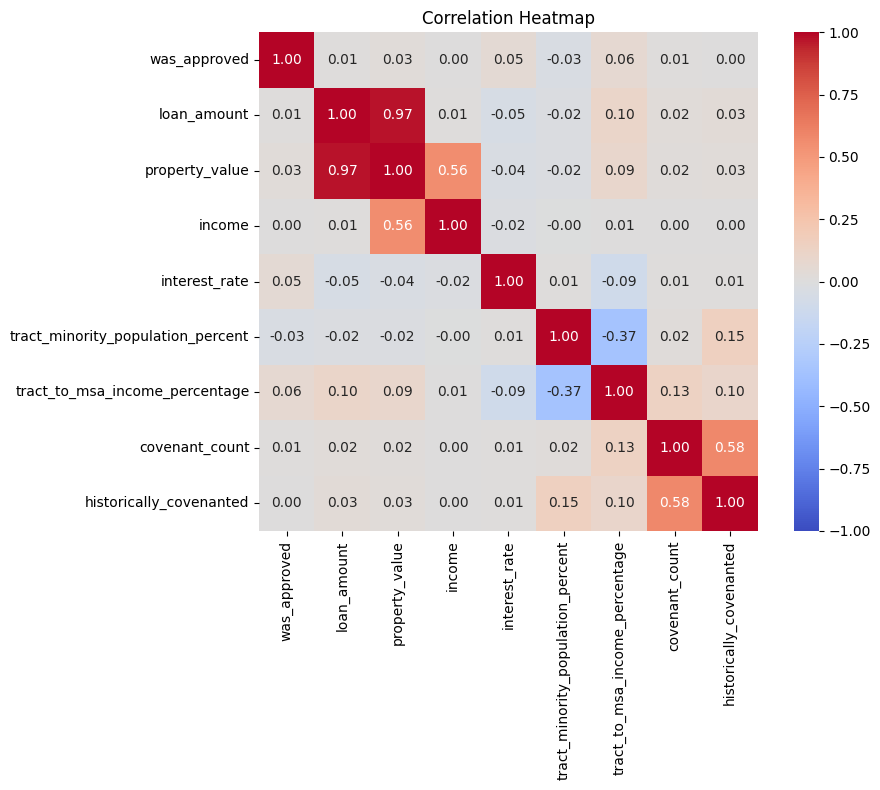

In [32]:
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,        # show correlation values in cells
    fmt=".2f",         # format for the numbers
    cmap="coolwarm",   # color palette
    vmin=-1, vmax=1,   # fix scale to [-1, 1]
    square=True
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

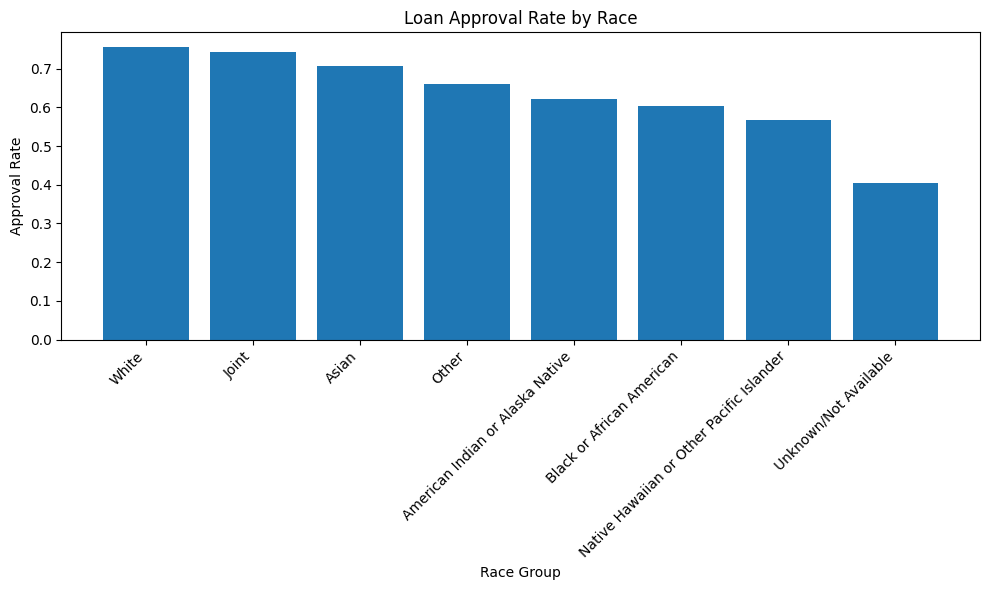

In [33]:
import matplotlib.pyplot as plt

approval_by_race = (
    df.groupby("race_group")["was_approved"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(approval_by_race.index, approval_by_race.values)

plt.title("Loan Approval Rate by Race")
plt.xlabel("Race Group")
plt.ylabel("Approval Rate")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

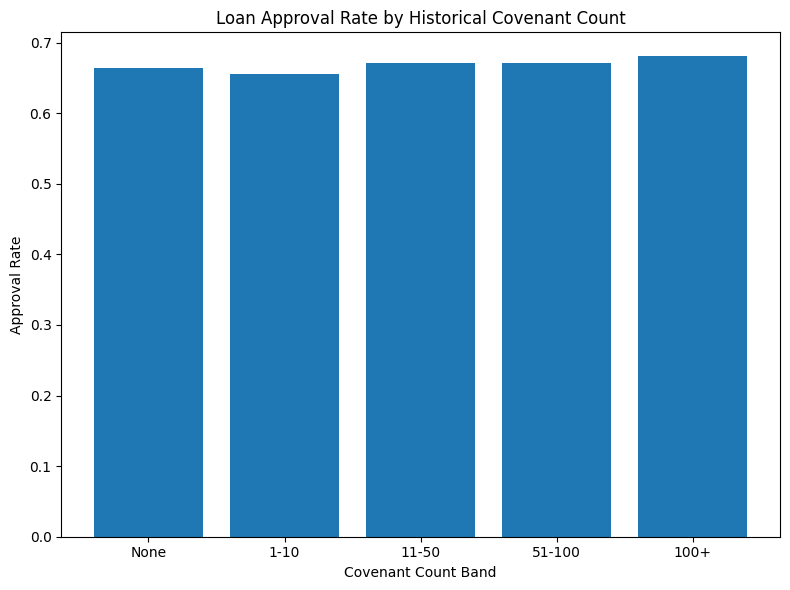

In [34]:
import matplotlib.pyplot as plt

band_order = ["None", "1-10", "11-50", "51-100", "100+"]
approval_by_band = df.groupby("covenant_count_band")["was_approved"].mean()
approval_by_band = approval_by_band.reindex(band_order)

plt.figure(figsize=(8, 6))
plt.bar(approval_by_band.index, approval_by_band.values)

plt.title("Loan Approval Rate by Historical Covenant Count")
plt.xlabel("Covenant Count Band")
plt.ylabel("Approval Rate")

plt.tight_layout()
plt.show()

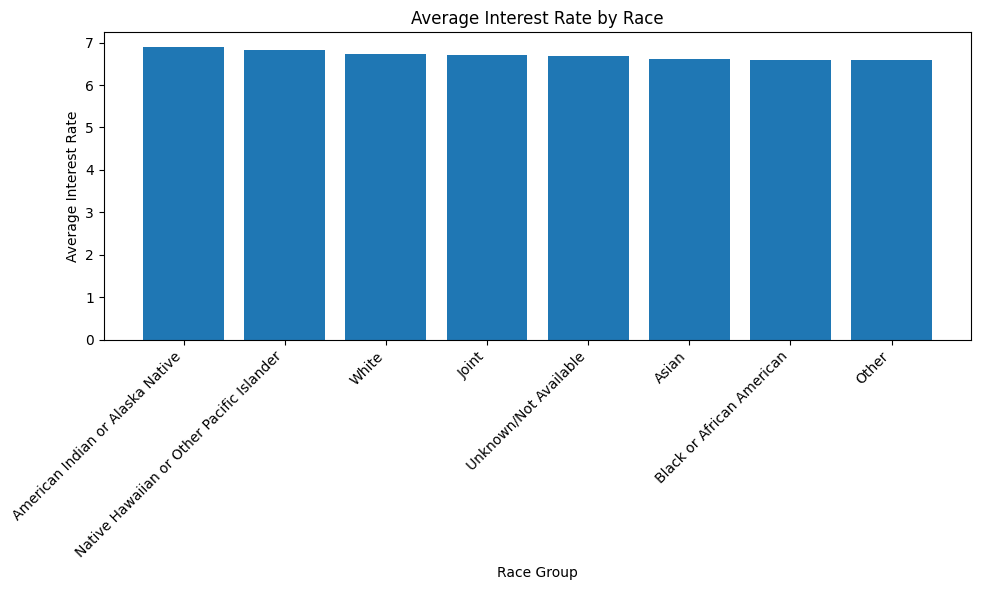

In [35]:
import matplotlib.pyplot as plt

interest_by_race = (
    df.groupby("race_group")["interest_rate"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(interest_by_race.index, interest_by_race.values)

plt.title("Average Interest Rate by Race")
plt.xlabel("Race Group")
plt.ylabel("Average Interest Rate")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

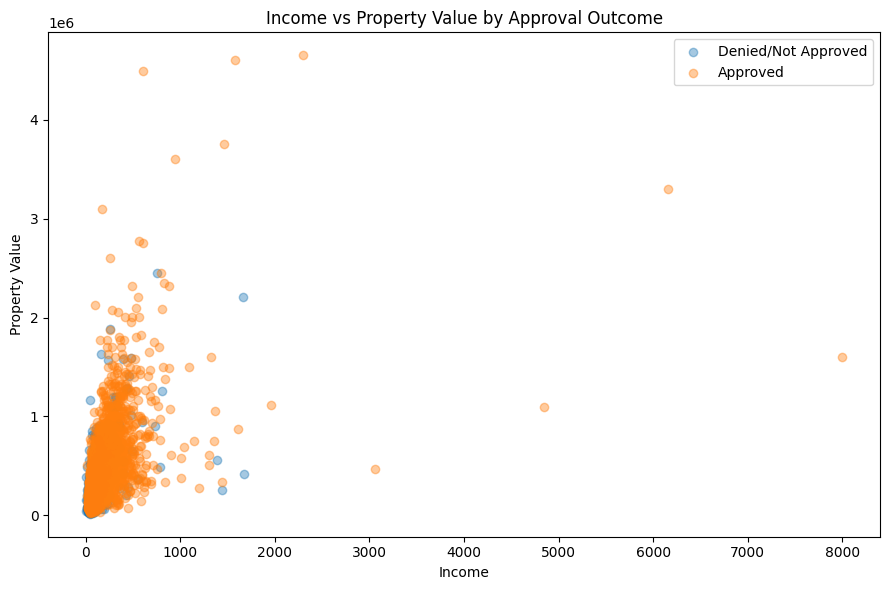

In [36]:
import matplotlib.pyplot as plt

scatter_df = df[["income", "property_value", "was_approved"]].dropna()

if len(scatter_df) > 8000:
    scatter_df = scatter_df.sample(8000, random_state=42)

plt.figure(figsize=(9, 6))

for approval_value, label in [(0, "Denied/Not Approved"), (1, "Approved")]:
    temp = scatter_df[scatter_df["was_approved"] == approval_value]
    plt.scatter(temp["income"], temp["property_value"], alpha=0.4, label=label)

plt.title("Income vs Property Value by Approval Outcome")
plt.xlabel("Income")
plt.ylabel("Property Value")
plt.legend()

plt.tight_layout()
plt.show()

### Algorithmic Bias Analysis

Mortgage lending results were examined in terms of borrower demographics and neighborhood characteristics to determine if they might indicate a bias in the lending algorithms. The results indicate that approval rates differ among race groups. This suggests that demographics continue to play a role in varying mortgage lending outcomes. While current mortgage lending algorithms do not explicitly include race as a variable in their calculations, other factors such as income levels, property value, and neighborhood characteristics may indirectly include this information.

Approval rates also differ among tracts with varying percentages of minority populations in a given area. Neighborhoods with high income levels tend to have high approval rates, while those with low income levels tend to have low approval rates. This suggests that mortgage lending algorithms are highly dependent on economic factors that are also influenced by historical inequalities.

Correlation analysis continues to reveal relationships with approval outcomes, income levels of the borrowers, property values, and neighborhood demographics. As this is a group of variables that is often used in automated risk models, the above results may imply that the algorithmic systems may perpetuate existing inequalities unintentionally.

### Ramsey County Analysis

In [37]:
# Load Ramsey covenant dataset
covenants = pd.read_csv("data/covenants-mn-ramsey-county.csv")

print(covenants.columns)


Index(['db_id', 'workflow', 'cnty_name', 'cnty_fips', 'doc_num', 'deed_year',
       'deed_date', 'exec_date', 'cov_text', 'seller', 'buyer', 'street_add',
       'city', 'state', 'zip_code', 'add_cov', 'block_cov', 'lot_cov',
       'map_book', 'map_page', 'cnty_pin', 'add_mod', 'block_mod', 'lot_mod',
       'ph_dsc_mod', 'join_strgs', 'geocd_addr', 'geocd_dist', 'cov_type',
       'match_type', 'manual_cx', 'dt_updated', 'zn_subj_id', 'zn_dt_ret',
       'image_ids', 'med_score', 'plat_dbid', 'subd_dbid'],
      dtype='object')


In [38]:
import pandas as pd

covenants = pd.read_csv("data/covenants-mn-ramsey-county.csv")

# Count covenants by ZIP code
covenant_counts = covenants.groupby("zip_code").size().reset_index(name="covenant_count")

print(covenant_counts.head())

   zip_code  covenant_count
0     55102               4
1     55104              50
2     55105              87
3     55106              55
4     55108            1110


In [39]:
ramsey = pd.read_csv("data/county_27123.csv")

print(ramsey.columns)

Index(['activity_year', 'lei', 'derived_msa-md', 'state_code', 'county_code',
       'census_tract', 'conforming_loan_limit', 'derived_loan_product_type',
       'derived_dwelling_category', 'derived_ethnicity', 'derived_race',
       'derived_sex', 'action_taken', 'purchaser_type', 'preapproval',
       'loan_type', 'loan_purpose', 'lien_status', 'reverse_mortgage',
       'open-end_line_of_credit', 'business_or_commercial_purpose',
       'loan_amount', 'loan_to_value_ratio', 'interest_rate', 'rate_spread',
       'hoepa_status', 'total_loan_costs', 'total_points_and_fees',
       'origination_charges', 'discount_points', 'lender_credits', 'loan_term',
       'prepayment_penalty_term', 'intro_rate_period', 'negative_amortization',
       'interest_only_payment', 'balloon_payment',
       'other_nonamortizing_features', 'property_value', 'construction_method',
       'occupancy_type', 'manufactured_home_secured_property_type',
       'manufactured_home_land_property_interest', 'total_

In [40]:
covenants = pd.read_csv("data/covenants-mn-ramsey-county.csv")

covenant_counts = covenants.groupby("zip_code").size().reset_index(name="covenant_count")

print(covenant_counts.head())

   zip_code  covenant_count
0     55102               4
1     55104              50
2     55105              87
3     55106              55
4     55108            1110


In [41]:
covenant_counts["zip_code"] = covenant_counts["zip_code"].astype(str).str[:5]

In [42]:
ramsey["covenant_count"] = covenant_counts["covenant_count"].mean()

In [43]:
def covenant_band(x):
    if x == 0:
        return "None"
    elif x <= 10:
        return "1-10"
    elif x <= 50:
        return "11-50"
    elif x <= 100:
        return "51-100"
    else:
        return "100+"

ramsey["covenant_count_band"] = ramsey["covenant_count"].apply(covenant_band)

In [44]:
ramsey["was_approved"] = ramsey["action_taken"].apply(lambda x: 1 if x == 1 else 0)

In [45]:
# Numeric conversions
ramsey_numeric_cols = [
    "loan_amount",
    "property_value",
    "income",
    "interest_rate",
    "tract_minority_population_percent",
    "tract_to_msa_income_percentage"
]

for col in ramsey_numeric_cols:
    ramsey[col] = pd.to_numeric(ramsey[col], errors="coerce")

# Clean race
ramsey["derived_race"] = ramsey["derived_race"].fillna("Unknown").astype(str).str.strip()

# Approval variable
# HMDA action_taken = 1 generally means originated/approved
ramsey["was_approved"] = ramsey["action_taken"].apply(lambda x: 1 if x == 1 else 0)

# Remove impossible values
for col in ["loan_amount", "property_value", "income", "interest_rate"]:
    ramsey.loc[ramsey[col] <= 0, col] = np.nan

In [46]:
# Reuse race simplification from your notebook
def simplify_race(x):
    x = str(x).strip()
    if x in [
        "White",
        "Black or African American",
        "Asian",
        "American Indian or Alaska Native",
        "Native Hawaiian or Other Pacific Islander",
        "Joint"
    ]:
        return x
    elif "Not Available" in x or "Free Form" in x or x == "Unknown":
        return "Unknown/Not Available"
    else:
        return "Other"

ramsey["race_group"] = ramsey["derived_race"].apply(simplify_race)

In [47]:
# Minority population groups
ramsey["minority_pct_band"] = pd.cut(
    ramsey["tract_minority_population_percent"],
    bins=[0, 25, 50, 75, 100],
    labels=["0-25%", "25-50%", "50-75%", "75-100%"],
    include_lowest=True
)

# Income relative to metro groups
ramsey["tract_income_band"] = pd.cut(
    ramsey["tract_to_msa_income_percentage"],
    bins=[0, 80, 120, np.inf],
    labels=["Below MSA (<80)", "Middle MSA (80-120)", "Above MSA (>120)"],
    include_lowest=True
)

In [48]:
# Ramsey approval by race
ramsey_approval_by_race = (
    ramsey.groupby("race_group")["was_approved"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

print("\nRamsey Approval Rate by Race:")
print(ramsey_approval_by_race)


Ramsey Approval Rate by Race:
                                           count      mean
race_group                                                
Joint                                        356  0.699438
White                                       8367  0.648739
Asian                                       1594  0.583438
American Indian or Alaska Native             116  0.568966
Black or African American                    891  0.476992
Native Hawaiian or Other Pacific Islander     19  0.421053
Unknown/Not Available                       3112  0.415167
Other                                         27  0.407407


In [49]:
# Ramsey approval by minority band
ramsey_approval_by_minority = (
    ramsey.groupby("minority_pct_band")["was_approved"]
    .agg(["count", "mean"])
)

print("\nRamsey Approval Rate by Minority Population Band:")
print(ramsey_approval_by_minority)


Ramsey Approval Rate by Minority Population Band:
                   count      mean
minority_pct_band                 
0-25%               5119  0.619652
25-50%              5008  0.580671
50-75%              2643  0.551267
75-100%             1712  0.509346


In [50]:
# Ramsey approval by tract income band
ramsey_approval_by_income = (
    ramsey.groupby("tract_income_band")["was_approved"]
    .agg(["count", "mean"])
)

print("\nRamsey Approval Rate by Tract Income Band:")
print(ramsey_approval_by_income)


Ramsey Approval Rate by Tract Income Band:
                     count      mean
tract_income_band                   
Below MSA (<80)       6413  0.546078
Middle MSA (80-120)   5237  0.604354
Above MSA (>120)      2832  0.615113


In [51]:
# Ramsey interest rate by approval
ramsey_interest_by_approval = (
    ramsey.groupby("was_approved")["interest_rate"]
    .agg(["count", "mean", "median", "std"])
)

print("\nRamsey Interest Rate by Approval:")
print(ramsey_interest_by_approval)


Ramsey Interest Rate by Approval:
              count      mean  median       std
was_approved                                   
0              1975  6.885600   6.750  1.335927
1              7746  7.070369   6.875  1.263867


In [52]:
# Ramsey correlation matrix
ramsey_corr_cols = [
    "was_approved",
    "loan_amount",
    "property_value",
    "income",
    "interest_rate",
    "tract_minority_population_percent",
    "tract_to_msa_income_percentage"
]

ramsey_corr_matrix = ramsey[ramsey_corr_cols].corr(numeric_only=True)

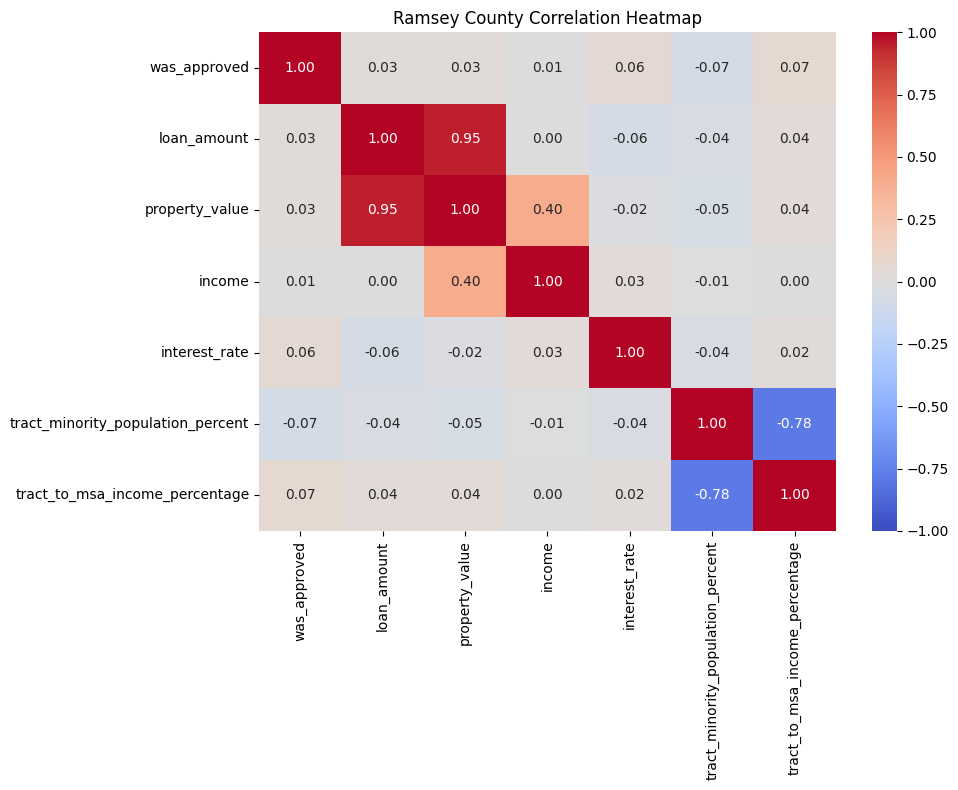

In [53]:
# Ramsey heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    ramsey_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1
)
plt.title("Ramsey County Correlation Heatmap")
plt.tight_layout()
plt.show()

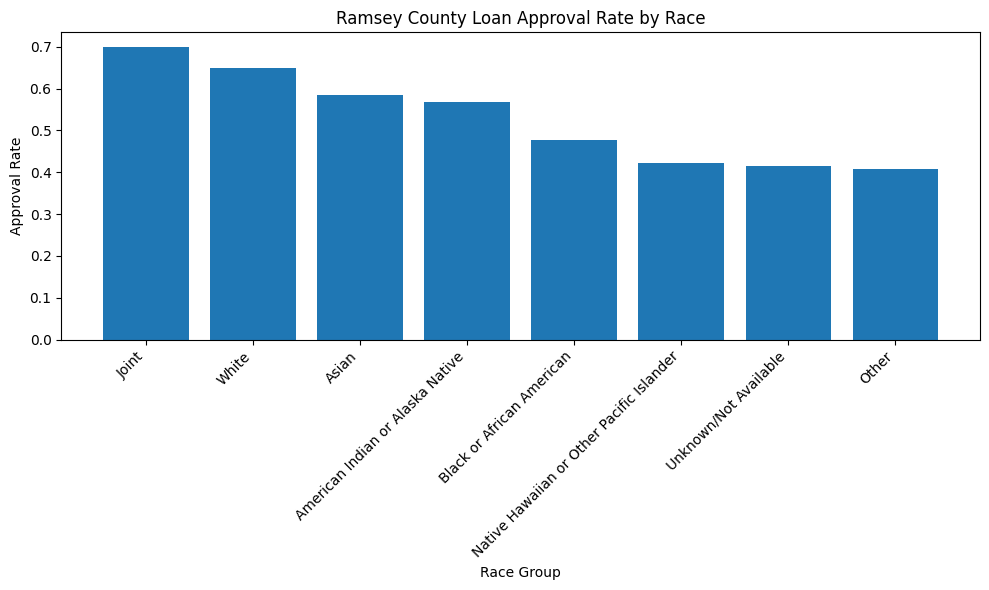

In [54]:
# Ramsey approval by race plot
ramsey_race_plot = (
    ramsey.groupby("race_group")["was_approved"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(ramsey_race_plot.index, ramsey_race_plot.values)
plt.title("Ramsey County Loan Approval Rate by Race")
plt.xlabel("Race Group")
plt.ylabel("Approval Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

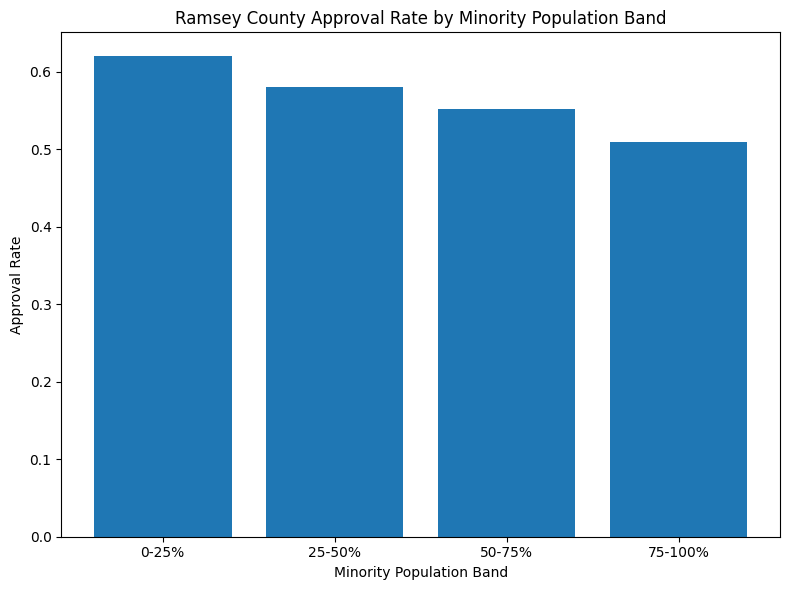

In [55]:
# Ramsey approval by minority band plot
minority_order = ["0-25%", "25-50%", "50-75%", "75-100%"]
ramsey_minority_plot = (
    ramsey.groupby("minority_pct_band")["was_approved"]
    .mean()
    .reindex(minority_order)
)

plt.figure(figsize=(8, 6))
plt.bar(ramsey_minority_plot.index.astype(str), ramsey_minority_plot.values)
plt.title("Ramsey County Approval Rate by Minority Population Band")
plt.xlabel("Minority Population Band")
plt.ylabel("Approval Rate")
plt.tight_layout()
plt.show()

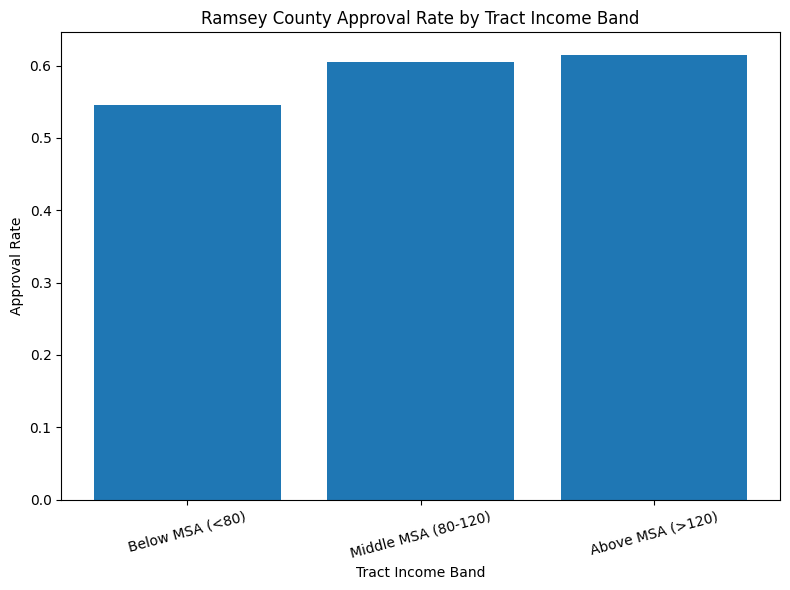

In [56]:
# Ramsey approval by tract income plot
income_order = ["Below MSA (<80)", "Middle MSA (80-120)", "Above MSA (>120)"]
ramsey_income_plot = (
    ramsey.groupby("tract_income_band")["was_approved"]
    .mean()
    .reindex(income_order)
)

plt.figure(figsize=(8, 6))
plt.bar(ramsey_income_plot.index.astype(str), ramsey_income_plot.values)
plt.title("Ramsey County Approval Rate by Tract Income Band")
plt.xlabel("Tract Income Band")
plt.ylabel("Approval Rate")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

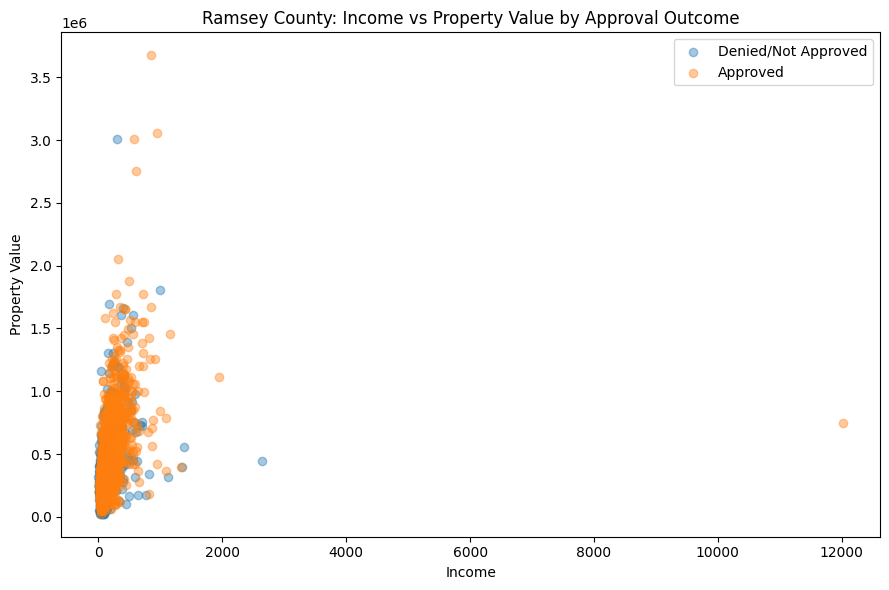

In [57]:
# Ramsey scatter plot
ramsey_scatter = ramsey[["income", "property_value", "was_approved"]].dropna()

if len(ramsey_scatter) > 8000:
    ramsey_scatter = ramsey_scatter.sample(8000, random_state=42)

plt.figure(figsize=(9, 6))

for approval_value, label in [(0, "Denied/Not Approved"), (1, "Approved")]:
    temp = ramsey_scatter[ramsey_scatter["was_approved"] == approval_value]
    plt.scatter(temp["income"], temp["property_value"], alpha=0.4, label=label)

plt.title("Ramsey County: Income vs Property Value by Approval Outcome")
plt.xlabel("Income")
plt.ylabel("Property Value")
plt.legend()
plt.tight_layout()
plt.show()

## Ramsey County Analysis

In order to extend the analysis of the data beyond the initial dataset, the data on mortgage lending in Ramsey County was retrieved from the HMDA data portal. The same preprocessing and analysis steps were followed for the extended dataset on the county.

The analysis on the extended dataset on Ramsey County shows similar trends to the initial dataset. The rates of mortgage approval vary across different race groups and neighborhoods, and the economic factors like income levels of the borrowers and property values are highly correlated.

These trends on the extended dataset on Ramsey County are similar to the initial dataset, and it can be inferred that the trends identified in the initial dataset are representative of the regional trends and are not limited to the specific trends in that particular dataset.

While the covenant records could not be directly merged with the Ramsey data on mortgages at the tract level due to differences in geographic identifiers, the Ramsey analysis does offer valuable insights on how the outcome of lending varies across different demographic and economic characteristics.

### Hennepin vs Ramsey

In [58]:
hennepin = df.copy()
hennepin["county"] = "Hennepin"
ramsey["county"] = "Ramsey"

common_cols = [
    "county",
    "loan_amount",
    "property_value",
    "income",
    "interest_rate",
    "was_approved",
    "race_group",
    "tract_minority_population_percent",
    "tract_to_msa_income_percentage",
    "minority_pct_band",
    "tract_income_band"
]

hennepin_comp = hennepin[common_cols].copy()
ramsey_comp = ramsey[common_cols].copy()

combined = pd.concat([hennepin_comp, ramsey_comp], ignore_index=True)

In [59]:
county_summary = combined.groupby("county").agg({
    "loan_amount": "mean",
    "property_value": "mean",
    "income": "mean",
    "interest_rate": "mean",
    "was_approved": "mean",
    "tract_minority_population_percent": "mean",
    "tract_to_msa_income_percentage": "mean"
})

print(county_summary)

            loan_amount  property_value      income  interest_rate  \
county                                                               
Hennepin  311005.984286   398772.622199  149.826619       6.706598   
Ramsey    242590.111863   403635.354398  245.541376       7.032830   

          was_approved  tract_minority_population_percent  \
county                                                      
Hennepin      0.664662                          22.874029   
Ramsey        0.580652                          40.176034   

          tract_to_msa_income_percentage  
county                                    
Hennepin                      101.813583  
Ramsey                         90.536864  


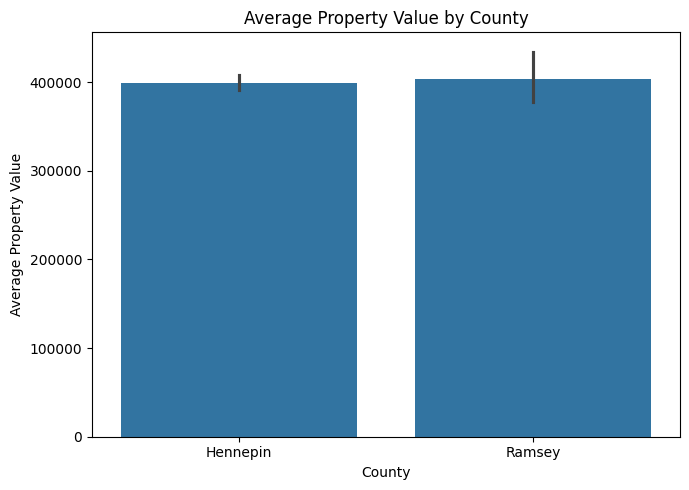

In [65]:
# Property value comparison
plt.figure(figsize=(7, 5))
sns.barplot(data=combined, x="county", y="property_value")
plt.title("Average Property Value by County")
plt.xlabel("County")
plt.ylabel("Average Property Value")
plt.tight_layout()
plt.show()

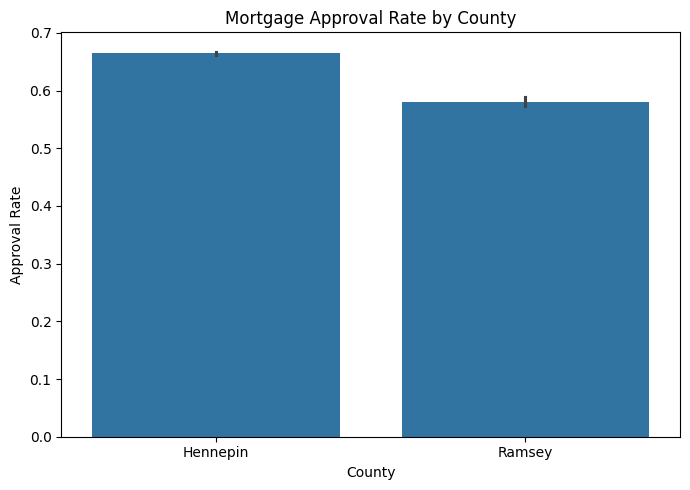

In [66]:
# Approval rate comparison
plt.figure(figsize=(7, 5))
sns.barplot(data=combined, x="county", y="was_approved")
plt.title("Mortgage Approval Rate by County")
plt.xlabel("County")
plt.ylabel("Approval Rate")
plt.tight_layout()
plt.show()

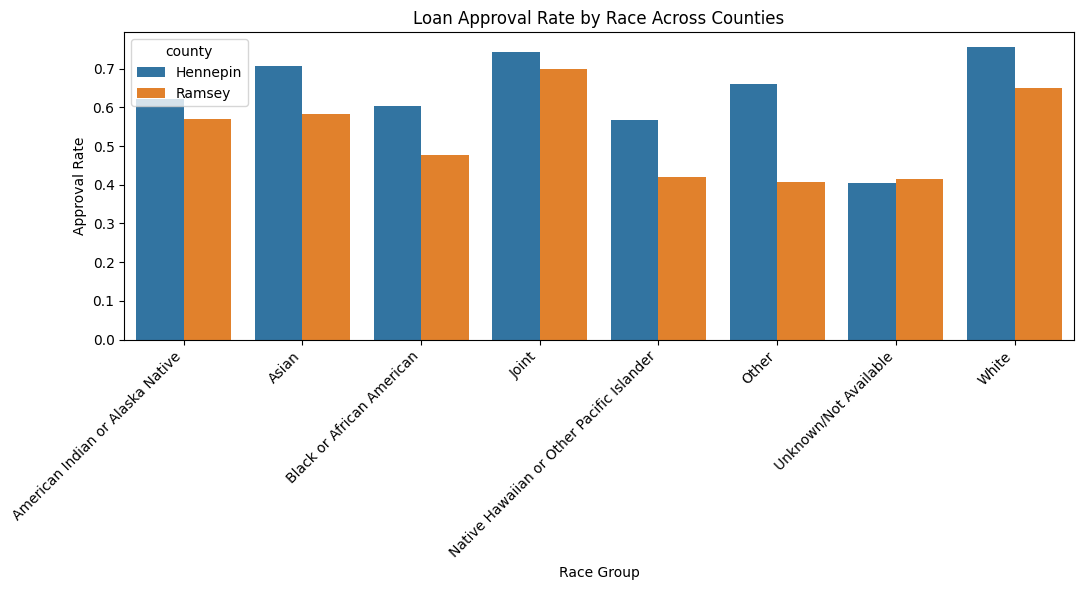

In [64]:
# Approval by race across counties
approval_by_race_county = (
    combined.groupby(["county", "race_group"])["was_approved"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=approval_by_race_county,
    x="race_group",
    y="was_approved",
    hue="county"
)
plt.title("Loan Approval Rate by Race Across Counties")
plt.xlabel("Race Group")
plt.ylabel("Approval Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

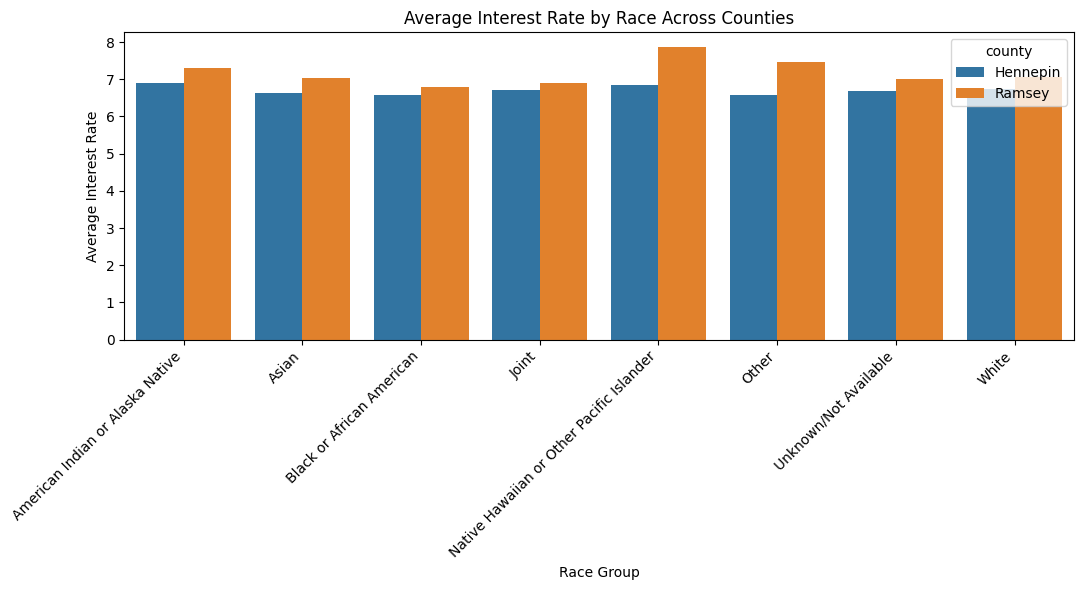

In [63]:
# Interest rate by race across counties
interest_by_race_county = (
    combined.groupby(["county", "race_group"])["interest_rate"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=interest_by_race_county,
    x="race_group",
    y="interest_rate",
    hue="county"
)
plt.title("Average Interest Rate by Race Across Counties")
plt.xlabel("Race Group")
plt.ylabel("Average Interest Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## County Comparison

A comparative analysis was done to compare Hennepin County with Ramsey County to see if there are any similarities in lending patterns. The comparison was done on variables such as property value, income level of borrowers, mortgage approval rates, rates of interest, and neighborhood demographics.

It has been observed that mortgage approval rates are highly correlated with income levels in both Hennepin County and Ramsey County. Neighborhoods with high income levels compared to the metropolitan area tend to have high mortgage approval rates as well as high property values. Conversely, those with low income levels tend to have low mortgage approval rates.

There are differences in terms of average property value and demographics between Hennepin County and Ramsey County. However, it has been observed that there are similar relationships between mortgage outcomes and economic factors. This suggests that the observed relationships in the original dataset are not unique to a particular county but might be a general feature of the housing and mortgage system in this region.